# Convert data into useful form

In [1]:
#import packages
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, image
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

In [2]:
# === Fetch AAL atlas ===
aal = datasets.fetch_atlas_aal()
aal_img = aal.maps        # path to AAL atlas NIfTI file
aal_labels = aal.labels   # list of ROI names

# === Fetch schaefer atlas ===
schaefer = datasets.fetch_atlas_schaefer_2018(
              n_rois        = 200,
              yeo_networks  = 17,
              resolution_mm = 2)     # align HCP volume (2mm)
schaefer_img   = schaefer.maps     # path to Schaefer atlas NIfTI file
schaefer_labels= schaefer.labels    # list of ROI names

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12
[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\schaefer_2018


## Edit Subject Here

In [ ]:
# === Subject number ===
subject = 100206

In [ ]:
# === Load fMRI data ===
BASE_DIR = Path(r"C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset")

def make_fmri_path(subject_id:int,
                   run_label:str="REST1_LR",
                   hp_tag:str="hp2000_clean") -> Path:
    
    return (BASE_DIR / 
            f"{subject_id:06d}" /
            "MNINonLinear" / 
            "Results" / 
            f"rfMRI_{run_label}" /
            f"rfMRI_{run_label}_{hp_tag}.nii.gz")

fmri_path = make_fmri_path(subject, "REST1_LR")
print("fMRI NIfTI:", fmri_path)

fMRI NIfTI: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\100206\MNINonLinear\Results\rfMRI_REST1_LR\rfMRI_REST1_LR_hp2000_clean.nii.gz


In [4]:
# === Parcellation ===
masker = NiftiLabelsMasker(labels_img   = aal_img,
                           standardize  = 'zscore_sample',
                           detrend      = True,
                           low_pass     = None,
                           high_pass    = None,
                           t_r          = 0.72,
                           resampling_target = 'data')   # keep atlas grid


ts = masker.fit_transform(str(fmri_path))
print("Extracted time-series shape:", ts.shape)   # (1200, 116) for AAL (1200, 200) for Schaefer

Extracted time-series shape: (1200, 116)


In [ ]:
# === sliding_window_corr ===
def sliding_window_corr(ts, win, step):
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P     = ts.shape
    n_windows = (T - win) // step + 1
    out      = np.zeros((n_windows, P, P), dtype=np.float32)
    for idx, s in enumerate(range(0, T - win + 1, step)):
        segment = ts[s:s+win ]
        corr_matrix = connectivity.fit_transform([segment])[0]
        out[idx] = corr_matrix
    return out

In [5]:
# === sliding_window_(1-|corr|) ===
def sliding_window_dist(ts, win, step):
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P     = ts.shape
    n_windows = (T - win) // step + 1
    out      = np.zeros((n_windows, P, P), dtype=np.float32)

    for idx, s in enumerate(range(0, T - win + 1, step)):
        segment = ts[s:s+win]
        corr_matrix = connectivity.fit_transform([segment])[0]
        dist_matrix = 1 - np.abs(corr_matrix) 
        out[idx] = dist_matrix

    return out


In [ ]:
def vectorize_upper_triangular(matrices):
    """
    Convert a batch of symmetric (P×P) matrices into vectors of upper triangle (excluding diag).
    Input:  matrices.shape = (N, P, P)
    Output: vectors.shape  = (N, P*(P-1)/2)
    """
    N, P, _ = matrices.shape
    idx = np.triu_indices(P, k=1)
    vecs = matrices[:, idx[0], idx[1]]
    return vecs

In [ ]:
ts_trimmed = ts[60:]  # Now ts_trimmed.shape = (1140, 116)

# Get correlation matrices
corr_matrices = sliding_window_corr(ts_trimmed, win=60, step=1)  # shape (1081, 116, 116) for step = 1

# Vectorize to (1081, 6670)
corr_vectors = vectorize_upper_triangular(corr_matrices)  # shape (1081, 6670) for step = 1

# Optional: Transpose to match MATLAB expectations (samples as columns)
corr_vectors_T = corr_vectors.T  # shape (6670, 1081)

In [6]:
ts_trimmed = ts[60:]  # Now ts_trimmed.shape = (1140, 116)

# Get distance matrices
dist_matrices = sliding_window_dist(ts_trimmed, win=60, step=1)  # shape (1081, 116, 116) for step = 1

# Vectorize to (1081, 6670)
# dist_vectors = vectorize_upper_triangular(dist_matrices)  # shape (1081, 6670) for step = 1

# Optional: Transpose to match MATLAB expectations (samples as columns)
# dist_vectors_T = dist_vectors.T  # shape (6670, 1081)

In [8]:
print(ts.shape, ts_trimmed.shape, corr_matrices.shape, corr_vectors.shape, corr_vectors_T.shape)

(1200, 116) (1140, 116) (1081, 116, 116) (1081, 6670) (6670, 1081)


In [8]:
print(ts.shape, ts_trimmed.shape, dist_matrices.shape)

(1200, 116) (1140, 116) (1081, 116, 116)


## Data Validiation Check

In [9]:
# === Checking correlation matrices ===
d = corr_matrices  # Shape: (n_windows, 116, 116)

results = {
    "num_windows"      : d.shape[0],
    "matrix_shape"     : d.shape[1:],
    "diag_all_one"     : bool(np.allclose(np.diagonal(d, axis1=1, axis2=2), 1.0)),
    "all_symmetric"    : bool(np.allclose(d, np.transpose(d, (0, 2, 1)))),
    "nan_count"        : int(np.isnan(d).sum()),
    "inf_count"        : int(np.isinf(d).sum()),
    "value_min"        : float(np.nanmin(d)),  # Use nan-safe version
    "value_max"        : float(np.nanmax(d)),
}

print("=== Correlation Matrix Diagnostics ===")
for k, v in results.items():
    print(f"{k:20s}: {v}")


=== Correlation Matrix Diagnostics ===
num_windows         : 1081
matrix_shape        : (116, 116)
diag_all_one        : True
all_symmetric       : True
nan_count           : 0
inf_count           : 0
value_min           : -0.7299522161483765
value_max           : 1.0


In [9]:
# === Checking distance matrices ===
d = dist_matrices  # Shape: (n_windows, 116, 116)

results = {
    "num_windows"      : d.shape[0],
    "matrix_shape"     : d.shape[1:],
    "diag_all_zero"    : bool(np.allclose(np.diagonal(d, axis1=1, axis2=2), 0.0)),
    "all_symmetric"    : bool(np.allclose(d, np.transpose(d, (0, 2, 1)))),
    "nan_count"        : int(np.isnan(d).sum()),
    "inf_count"        : int(np.isinf(d).sum()),
    "value_min"        : float(np.nanmin(d)),
    "value_max"        : float(np.nanmax(d)),
}

print("=== Distance Matrix Diagnostics ===")
for k, v in results.items():
    print(f"{k:20s}: {v}")


=== Distance Matrix Diagnostics ===
num_windows         : 1081
matrix_shape        : (116, 116)
diag_all_zero       : True
all_symmetric       : True
nan_count           : 0
inf_count           : 0
value_min           : 0.0
value_max           : 1.0


## Visualize

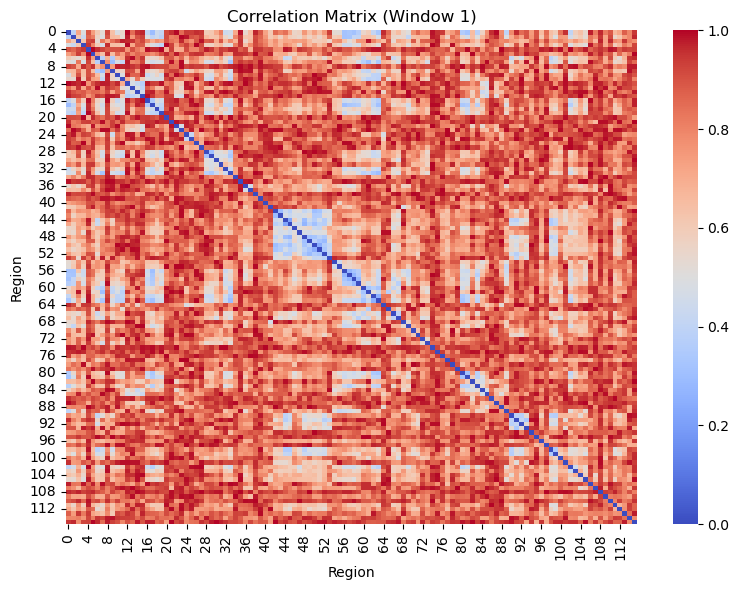

In [ ]:
# === Plot sample heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrices[0], cmap='coolwarm', vmin=0, vmax=1)
#sns.heatmap(corr_matrices[0], cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Window 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## Data Save

In [ ]:
# === Save corr as .npy file ===
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/rfMRI_ts")
outfile = OUT_DIR / f"{subject:06d}_REST1_LR_AAL_corr_vec.npy"
np.save(outfile, corr_vectors_T)

print(f"Saved 6670-D vectorized correlation series → {outfile}")

Saved 6670-D vectorized correlation series → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\rfMRI_ts\102311_REST1_LR_AAL_corr_vec.npy


In [11]:
# === Save dist as .npy file ===
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/rfMRI_ts")
outfile = OUT_DIR / f"{subject:06d}_REST1_LR_AAL_dist_mat.npy"
np.save(outfile, dist_matrices)

print(f"Saved distance matrices → {outfile}")

Saved distance matrices → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\rfMRI_ts\100206_REST1_LR_AAL_dist_mat.npy


In [ ]:
# Save corr as TXT
txtfile = OUT_DIR / f"{subject:06d}_REST1_LR_AAL_corr_vec.txt"
np.savetxt(txtfile, corr_vectors_T, fmt='%.6f')
print(f"Saved 6670-D correlation vector series as TXT → {txtfile}")

Saved 6670-D correlation vector series as TXT → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\rfMRI_ts\102311_REST1_LR_AAL_corr_vec.txt


In [ ]:
# Save dist as TXT
OUT_DIR = Path(f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/rfMRI_ts/{subject:06d}_REST1_dist")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# dist_matrices: shape (n_windows, 116, 116)
for i, mat in enumerate(dist_matrices):
    file_path = OUT_DIR / f"rs{subject}_dist_matrix_{i:03d}.txt"
    np.savetxt(file_path, mat, fmt='%.6f')
    #print(f"Saved → {file_path}")


In [ ]:
# Load the .txt file
txtfile = f'C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/rfMRI_ts/{subject:06d}_REST1_LR_AAL_corr_vec.txt'
data = np.loadtxt(txtfile)

# Sanity checks
print("=== TXT File Sanity Check ===")
print(f"Shape                : {data.shape}")  # Expecting (6670, 1081)
print(f"Number of entries    : {data.size}")
print(f"Expected entries     : 6670 * 1081 = {6670 * 1081}")
print(f"Min value            : {np.min(data):.4f}")
print(f"Max value            : {np.max(data):.4f}")
print(f"Any NaNs             : {np.isnan(data).any()}") # False: All values are real numbers
print(f"Any Infs             : {np.isinf(data).any()}") # False: All values are finite and valid

=== TXT File Sanity Check ===
Shape                : (6670, 1081)
Number of entries    : 7210270
Expected entries     : 6670 * 1081 = 7210270
Min value            : -0.7748
Max value            : 0.9224
Any NaNs             : False
Any Infs             : False


In [ ]:
# Load the .txt file
txtfile = f'C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/rfMRI_ts/100206_REST1_dist/rs{subject:06d}_dist_matrix_000.txt'
data = np.loadtxt(txtfile)

# Sanity checks
print("=== TXT File Sanity Check ===")
print(f"Shape                : {data.shape}")  # Expecting (116, 116)
print(f"Number of entries    : {data.size}")
print(f"Expected entries     : 116 * 116 = {116 * 116}")
print(f"Min value            : {np.min(data):.4f}")
print(f"Max value            : {np.max(data):.4f}")
print(f"Any NaNs             : {np.isnan(data).any()}") # False: All values are real numbers
print(f"Any Infs             : {np.isinf(data).any()}") # False: All values are finite and valid

=== TXT File Sanity Check ===
Shape                : (116, 116)
Number of entries    : 13456
Expected entries     : 6670 * 1081 = 7210270
Min value            : 0.0000
Max value            : 1.0000
Any NaNs             : False
Any Infs             : False
